In [1]:
path_to_dodem = '/Users/jmdunca2/do-dem/'
from sys import path as sys_path
sys_path.append(path_to_dodem+'/dodem/')

import HARP_and_age as haa
import all_nu_analysis as ana

import pickle
import importlib

import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u

from astropy.visualization import quantity_support
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x164b240a0>

In [2]:
with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
    all_targets = pickle.load(f)

7.068583470577035
$a$ –  1.5180063024144617 4.922216040176707
$T_{\mathrm{peak}}$ [MK] –  1.58 2.3
$a$ –  1.5180063024144617 4.922216040176707
$\log_{10}(EM_{\mathrm{peak}})$ –  26.05574119297303 26.86088783075433
$a$ –  1.5180063024144617 4.922216040176707
$\log_{10}(EM_{>5\mathrm{MK}})$ –  19.77914138178073 23.97749979424637
$a$ –  1.5180063024144617 4.922216040176707
$\log_{10}(EM_{>10\mathrm{MK}})$ –  17.25434872310056 20.701079482995286
$a$ –  1.5180063024144617 4.922216040176707
$b$ –  7.837828635125983 12.304046275824573
$a$ –  1.5180063024144617 4.922216040176707
$\log_{10}(R_{\frac{>10\mathrm{MK}}{\mathrm{peak}}})$ –  -8.910458345623903 -5.4367060188440695
$T_{\mathrm{peak}}$ [MK] –  1.58 2.3
$\log_{10}(EM_{\mathrm{peak}})$ –  26.05574119297303 26.86088783075433
$T_{\mathrm{peak}}$ [MK] –  1.58 2.3
$\log_{10}(EM_{>5\mathrm{MK}})$ –  19.77914138178073 23.97749979424637
$T_{\mathrm{peak}}$ [MK] –  1.58 2.3
$\log_{10}(EM_{>10\mathrm{MK}})$ –  17.25434872310056 20.701079482995286


/var/folders/55/06y21cm93w70z_8gl7yxv2t40000gq/T/ipykernel_31142/618218938.py:172: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bg_color_rgba = plt.cm.get_cmap(cmap)(norm(rr))


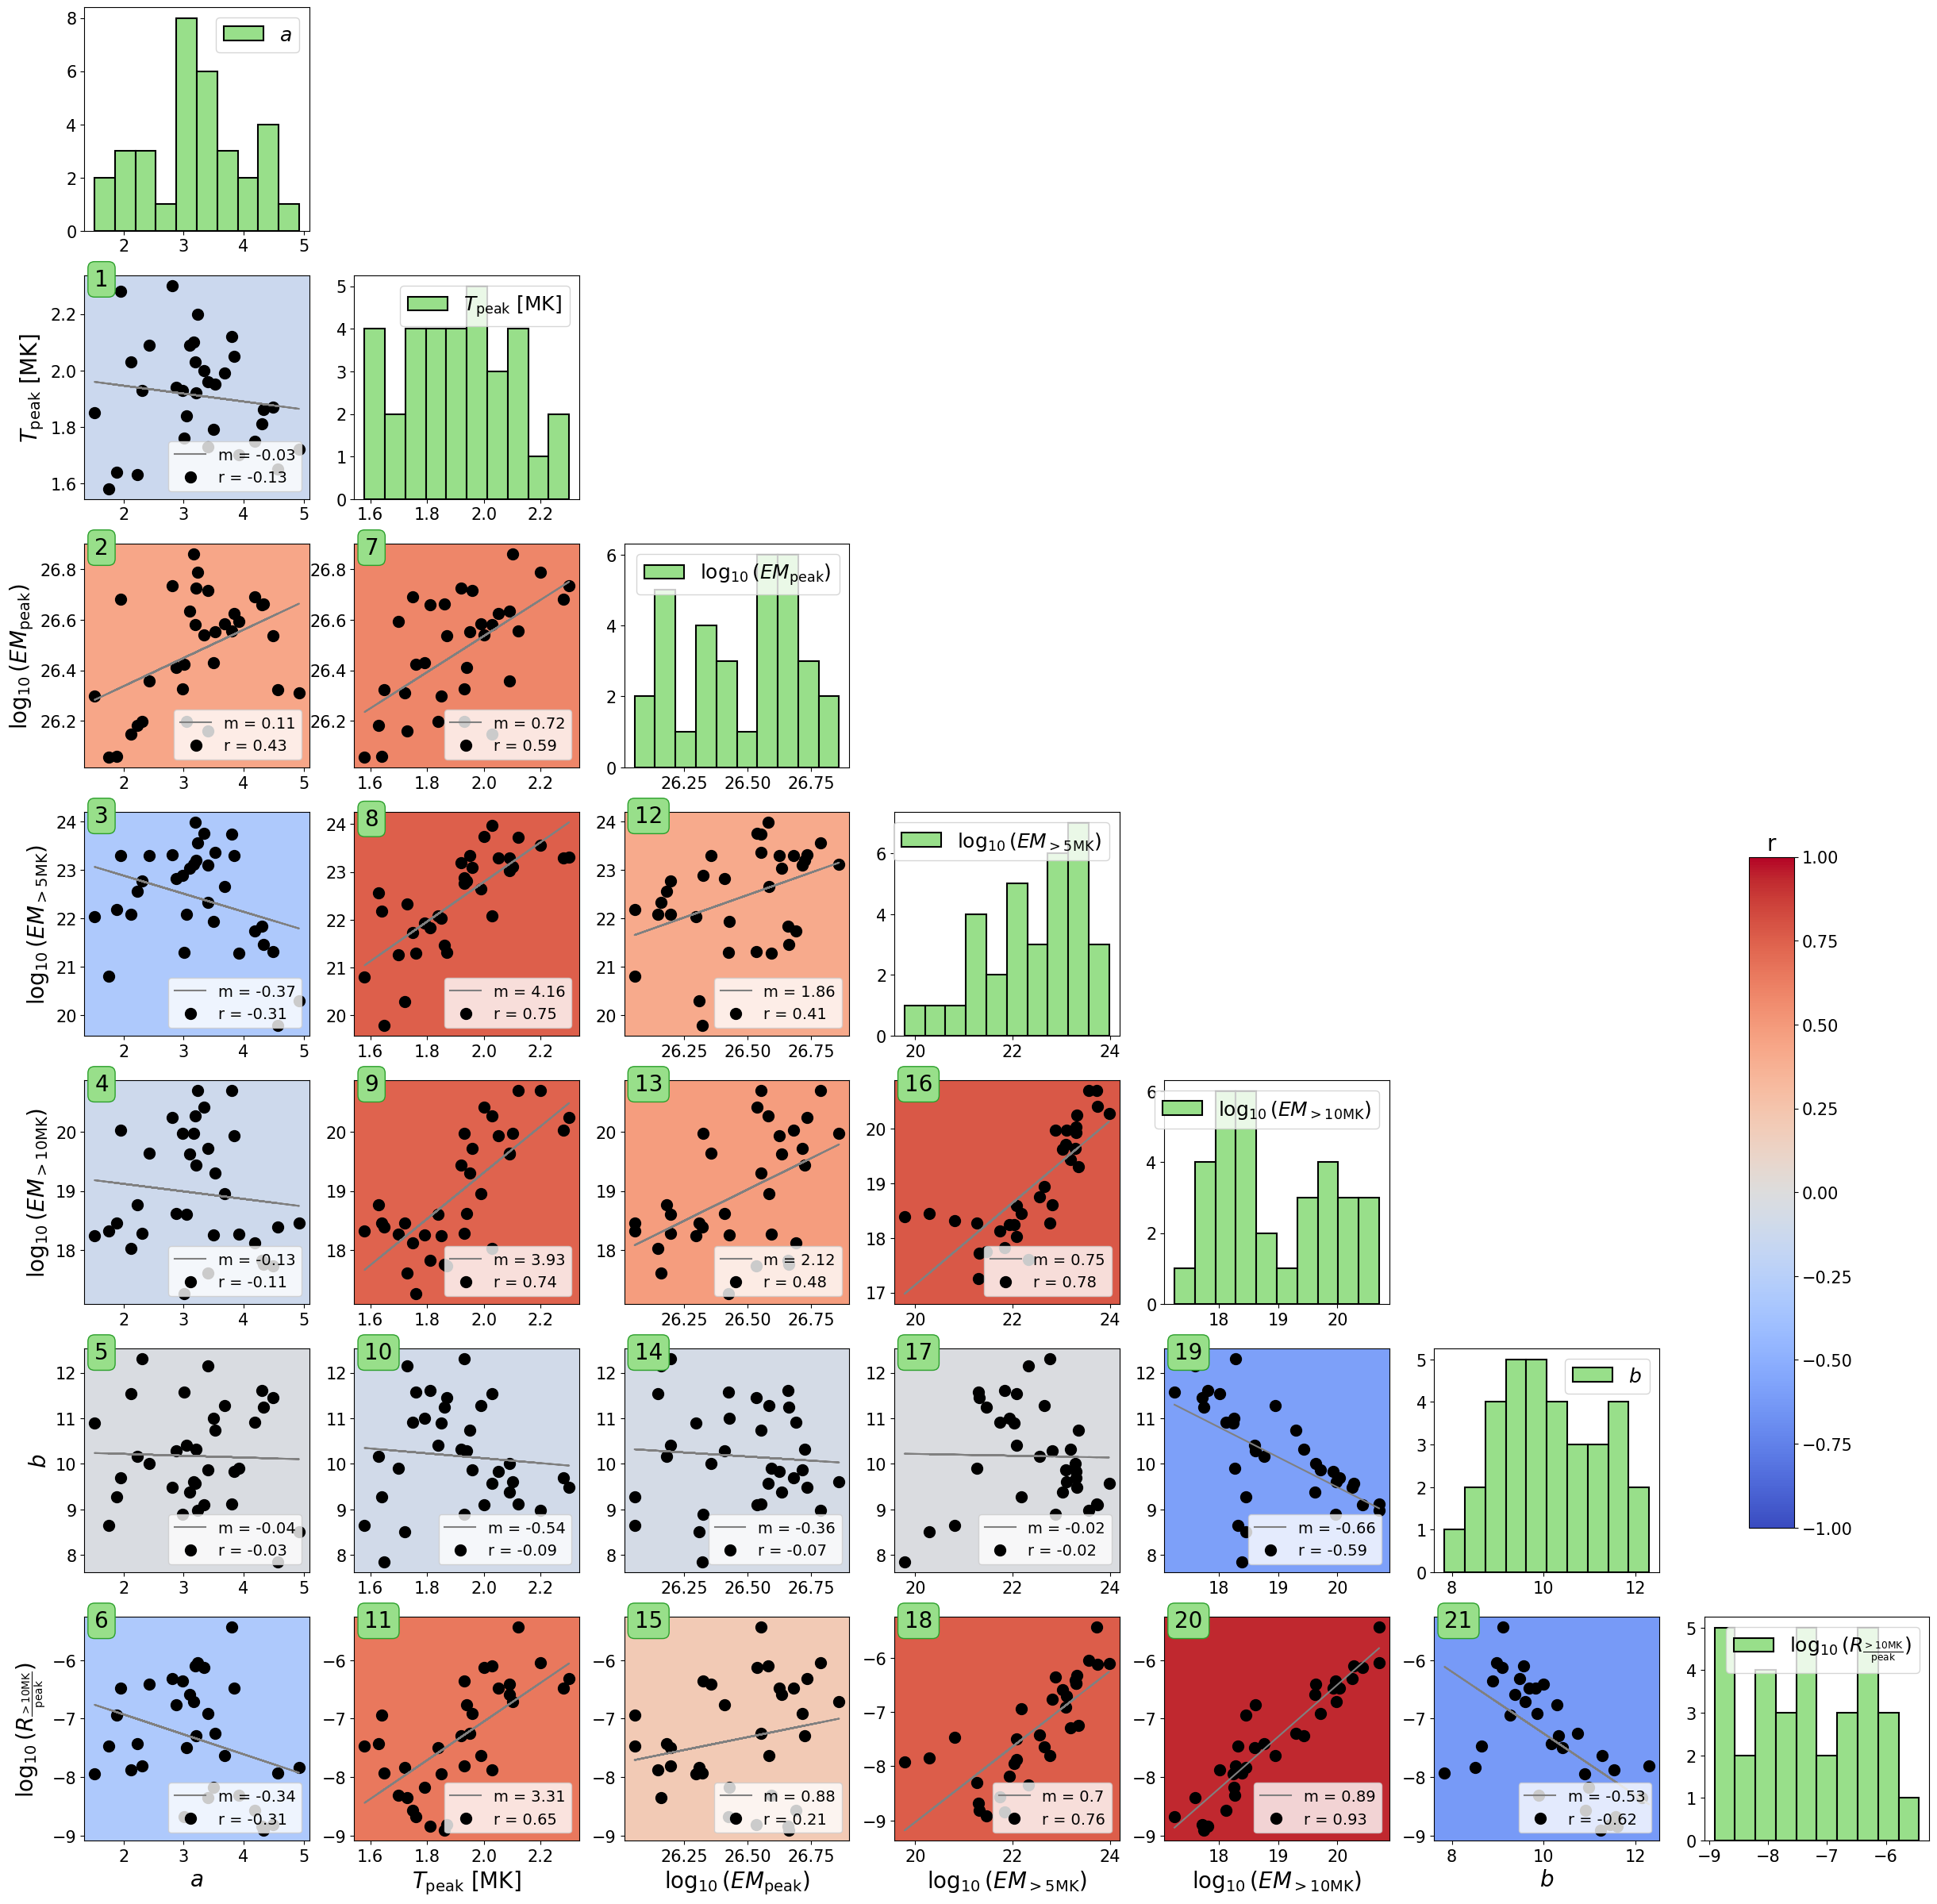

In [4]:


with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)

samesames = data['same region lists']
filelist = ana.get_same_region_file_lists(samesames, all_targets, get_agelists=False, noxrt=False)
#print(agelist)


def make_cornerplot(filelist, agelist=[], title='', histograms=False):

    if agelist:
        ages=[]
        for aa in agelist:
            all=[]
            for age in aa:
                all.append(age[0])
            ages.append(np.mean(np.array(all)))
        
    #print(len(agelist))
    
    #Factor to adjust integrated EM values
    area_i = 100**2
    area_m = np.pi*150**2
    #print(area_i, area_m)
    factor = area_m/area_i
    print(factor)
    factor=1
    
    
    allgood=0
    region_above10s=[]
    region_above7s=[]
    region_above5s=[]
    region_totaltime=[]

    region_10overpeak=[]
    
    region_peakTs=[]
    region_peakEMs=[]
    
    region_lower=[]
    region_upper=[]
    
    for i in range(0, len(filelist)):
        gf = filelist[i]
    
        vals = []
        above10s_ = []
        val7s = []
        above7s_ = []
        val5s = []
        above5s_ = []
        vals2 = []
        totaltime = 0
        peakTs = []
        peakEM = []
        lowp = []
        upp = []
        durs = []
        for f_ in gf:
            with open(f_, 'rb') as f:
                data = pickle.load(f)
            #print(f_)
            time = data['time_interval']
            dur = (time[1]-time[0]).to(u.s).value
            above10s = np.log10(data['above_10MK'])
            above7s = data['above_7MK']
            above5s = np.log10(data['above_5MK'])
            #print(data.keys())
            peakTs.append(10**data['max_temp']/1e6)
            peakEM.append(np.log10(data['max']))
            lowp.append(data['powerlaws2'][0][0])
            upp.append(-1*data['powerlaws2'][1][0])
            above10s_.append(above10s[0])
            vals.append([dur*above10s[0]])
            above7s_.append(above7s[0])
            val7s.append([dur*above7s[0]])
            above5s_.append(above5s[0])
            val5s.append([dur*above5s[0]])
            totaltime+=dur
            vals2.append([dur*data['above_10MK'][0]/data['max']])
            durs.append(dur)

        #print('val comp: ', np.std(above10s_), np.sum(vals)/totaltime*factor, np.mean(above10s_))
        #print(len(vals))
    
        #print(totaltime)
        if vals:
            #print(vals)
            #print(vals2)
            region_above10s.append([np.sum(vals)/totaltime*factor, np.min(above10s_)*factor, np.max(above10s_)*factor])
            region_above7s.append([np.sum(val7s)/totaltime*factor, np.min(above7s_)*factor, np.max(above7s_)*factor])
            region_above5s.append([np.sum(val5s)/totaltime*factor, np.min(above5s_)*factor, np.max(above5s_)*factor])
            region_10overpeak.append([np.sum(vals2)/totaltime, np.min(vals2)/durs[np.where(vals2 == np.min(vals2))[0][0]], 
                                                              np.max(vals2)/durs[np.where(vals2 == np.max(vals2))[0][0]]])
            region_totaltime.append(totaltime)
            region_peakTs.append(round(np.mean(peakTs), 2))
            region_peakEMs.append(np.mean(peakEM))
            region_lower.append(np.mean(lowp))
            region_upper.append(np.mean(upp))
        else:
            region_above10s.append([0, 0, 0])
            region_above7s.append([0, 0, 0])
            region_above5s.append([0, 0, 0])
            region_10overpeak.append([0, 0, 0])
            region_totaltime.append(0)
            region_peakTs.append(0)
            region_peakEMs.append(0)    
            region_lower.append(0)
            region_upper.append(0)


    #print([samesames[n] for n in np.where(np.array(region_10overpeak)[:,0] > 3e-6)[0]])
    #print([samesames[n] for n in np.where(np.array(region_above10s)[:,0] > 0.8e21)[0]])
    #for i in range(0, len(np.where(np.array(region_peakTs) < 1)[0])):
    #    print(samesames[np.where(np.array(region_peakTs) < 1)[0][i]])
    
    
    
    order = np.argsort(np.array(region_above10s)[:,0])
    
    above10s_vals_inorder = np.array(region_above10s)[:,0][order]#/1e21
    above7s_vals_inorder = np.array(region_above7s)[:,0][order]/1e23
    above5s_vals_inorder = np.array(region_above5s)[:,0][order]#/1e24
    peakTs_inorder = np.array(region_peakTs)[order]
    peakEMs_inorder = np.array(region_peakEMs)[order]#/1e26
    lower_inorder = np.array(region_lower)[order]
    upper_inorder = np.array(region_upper)[order]
    rat10overpeak_inorder = np.log10(np.array(region_10overpeak)[:,0][order])
    
    if agelist:
        ages_inorder = np.array(ages)[order]

    
    params=[#ages_inorder,
            lower_inorder, peakTs_inorder, peakEMs_inorder, 
            above5s_vals_inorder, 
            #above7s_vals_inorder, 
            above10s_vals_inorder, 
            upper_inorder,
           rat10overpeak_inorder]
    
    plabels=[#'AR Age (days)',
             r'$a$',
             r'$T_{\mathrm{peak}}$ [MK]', #r'$\log_{10}({T_{\mathrm{peak}}})$', 
             r'$\log_{10}(EM_{\mathrm{peak}})$', #($10^{26}$ '+(u.cm**(-5)).to_string('latex_inline')+')',
             r'$\log_{10}(EM_{>5\mathrm{MK}})$', # ($10^{24}$ '+(u.cm**(-5)).to_string('latex_inline')+')',
             #r'EM >7 MK ($10^{23}$ '+(u.cm**(-5)).to_string('latex_inline')+')', 
             r'$\log_{10}(EM_{>10\mathrm{MK}})$', # ($10^{21}$ '+(u.cm**(-5)).to_string('latex_inline')+')',
             r'$b$', 
             r'$\log_{10}(R_{\frac{>10\mathrm{MK}}{\mathrm{peak}}})$']
    

    fig, axes = plt.subplots(len(plabels), len(plabels), figsize=(30,30))
        
    from matplotlib.colors import TwoSlopeNorm
    from matplotlib import cm
    cmap = 'coolwarm'
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    plot_number=1
    for i in range(0, len(plabels)):
        for j in range(0, len(plabels)):
            ax = axes[j,i]
            if j > i:

                #To print parameter ranges:
                #print(plabels[i], '– ', np.min(params[i]), np.max(params[i]))
                #print(plabels[j], '– ', np.min(params[j]), np.max(params[j]))
                
                rr=round(np.corrcoef(params[i], params[j])[0,1],2)
    
                bg_color_rgba = plt.cm.get_cmap(cmap)(norm(rr))
                
                # Set the background color (facecolor) of the subplot axis
                ax.set_facecolor(bg_color_rgba)
            
        
                ax.errorbar(params[i], params[j], 
                            #xerr=xerr,
                           linestyle='', marker='o', linewidth=3, markersize=10, color='black', 
                            label='r = '+str(rr), zorder=0)
                ax.text(np.min(params[i]), np.max(params[j]), str(plot_number), fontsize=20, 
                       bbox=dict(boxstyle="round",
                           ec='#2CA02C', #(1., 0.5, 0.5),
                           fc='#98DF8A', #(1., 0.8, 0.8),
                   ))
                plot_number+=1
        
                #Fit option with y weights only
                m, b = np.polyfit(params[i], params[j], 1)
                fity = np.array(params[i])*m + b
                ax.plot(params[i], fity, label='m = '+str(round(m,2)), color='grey')  
                if i==0:
                    ax.set_ylabel(plabels[j], fontsize=20)
                if j==len(plabels)-1:
                    ax.set_xlabel(plabels[i], fontsize=20)
    
                ax.legend(loc='lower right', fontsize=14)
                ax.tick_params(labelsize=15)
    
            else:
                if not i==j:
                    ax.set_axis_off()
    
            if [i, j] == [len(plabels)-1,len(plabels)-3]:
                cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.8, shrink=3, aspect=15)
                cbar.ax.tick_params(labelsize=15)
                cbar.ax.set_title('r', fontsize=20)
                
    if histograms:
        for i in range(0, len(plabels)):
            ax=axes[i,i]
            ax.hist(params[i], bins=10, #histtype='step', 
                    edgecolor='black', facecolor='#98DF8A', linewidth=1.5, label=plabels[i])
            ax.tick_params(labelsize=15)
            ax.legend(loc='upper right', fontsize=18)
            #counts, edges = np.histogram(params[i], bins=10)
            #ax.step(edges[0:-1],counts, color='black')
        
    
    plt.savefig('makeshift_corner_5_10only_logEM_'+title+'new_uncert.png', dpi=300)


make_cornerplot(filelist, title='ghostcorr', histograms=True)

dict_keys(['time_interval', 'nuenergies', 'nufpm', 'temp_interval', 'plotMK', 'ts', 'ts_', 'mts', 'trmatrix', 'dn_in', 'edn_in', 'chanax', 'nustar_datapath', 'DEM', 'dn_reg', 'edem', 'edn', 'chisq', 'edn_string', 'fill_color', 'mnrat', 'local_maxima', 'max', 'max_temp', 'above_5MK', 'above_7MK', 'above_10MK', 'above_peak', 'below_peak', 'powerlaws', 'powerlaws2', 'powerlaws3', 'powerlaws4', 'powerlaws5', 'EMT_all', 'EMT_thresh_5'])
[(3.234820195710763, 0.1064121654253945, 6.391316785191447), (-8.51278447542232, 0.1027158934510824, 81.86117391255054)]


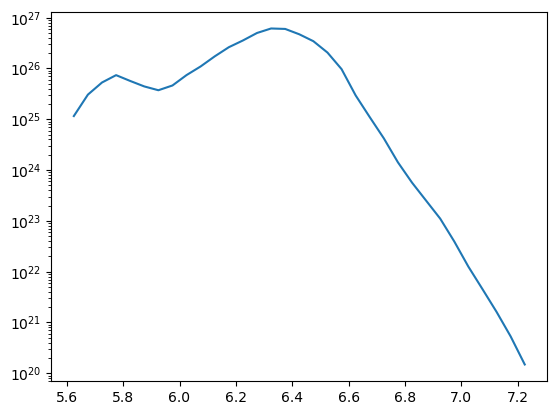

In [10]:
for i in range(0, len(filelist)):
        gf = filelist[i]
        for f_ in gf[0:1]:
            with open(f_, 'rb') as f:
                data = pickle.load(f)

print(data.keys())

plt.plot(data['ts'], data['DEM'])
plt.yscale('log')

print(data['powerlaws2'])

7.068583470577035


/var/folders/55/06y21cm93w70z_8gl7yxv2t40000gq/T/ipykernel_44379/171888186.py:174: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bg_color_rgba = plt.cm.get_cmap(cmap)(norm(rr))


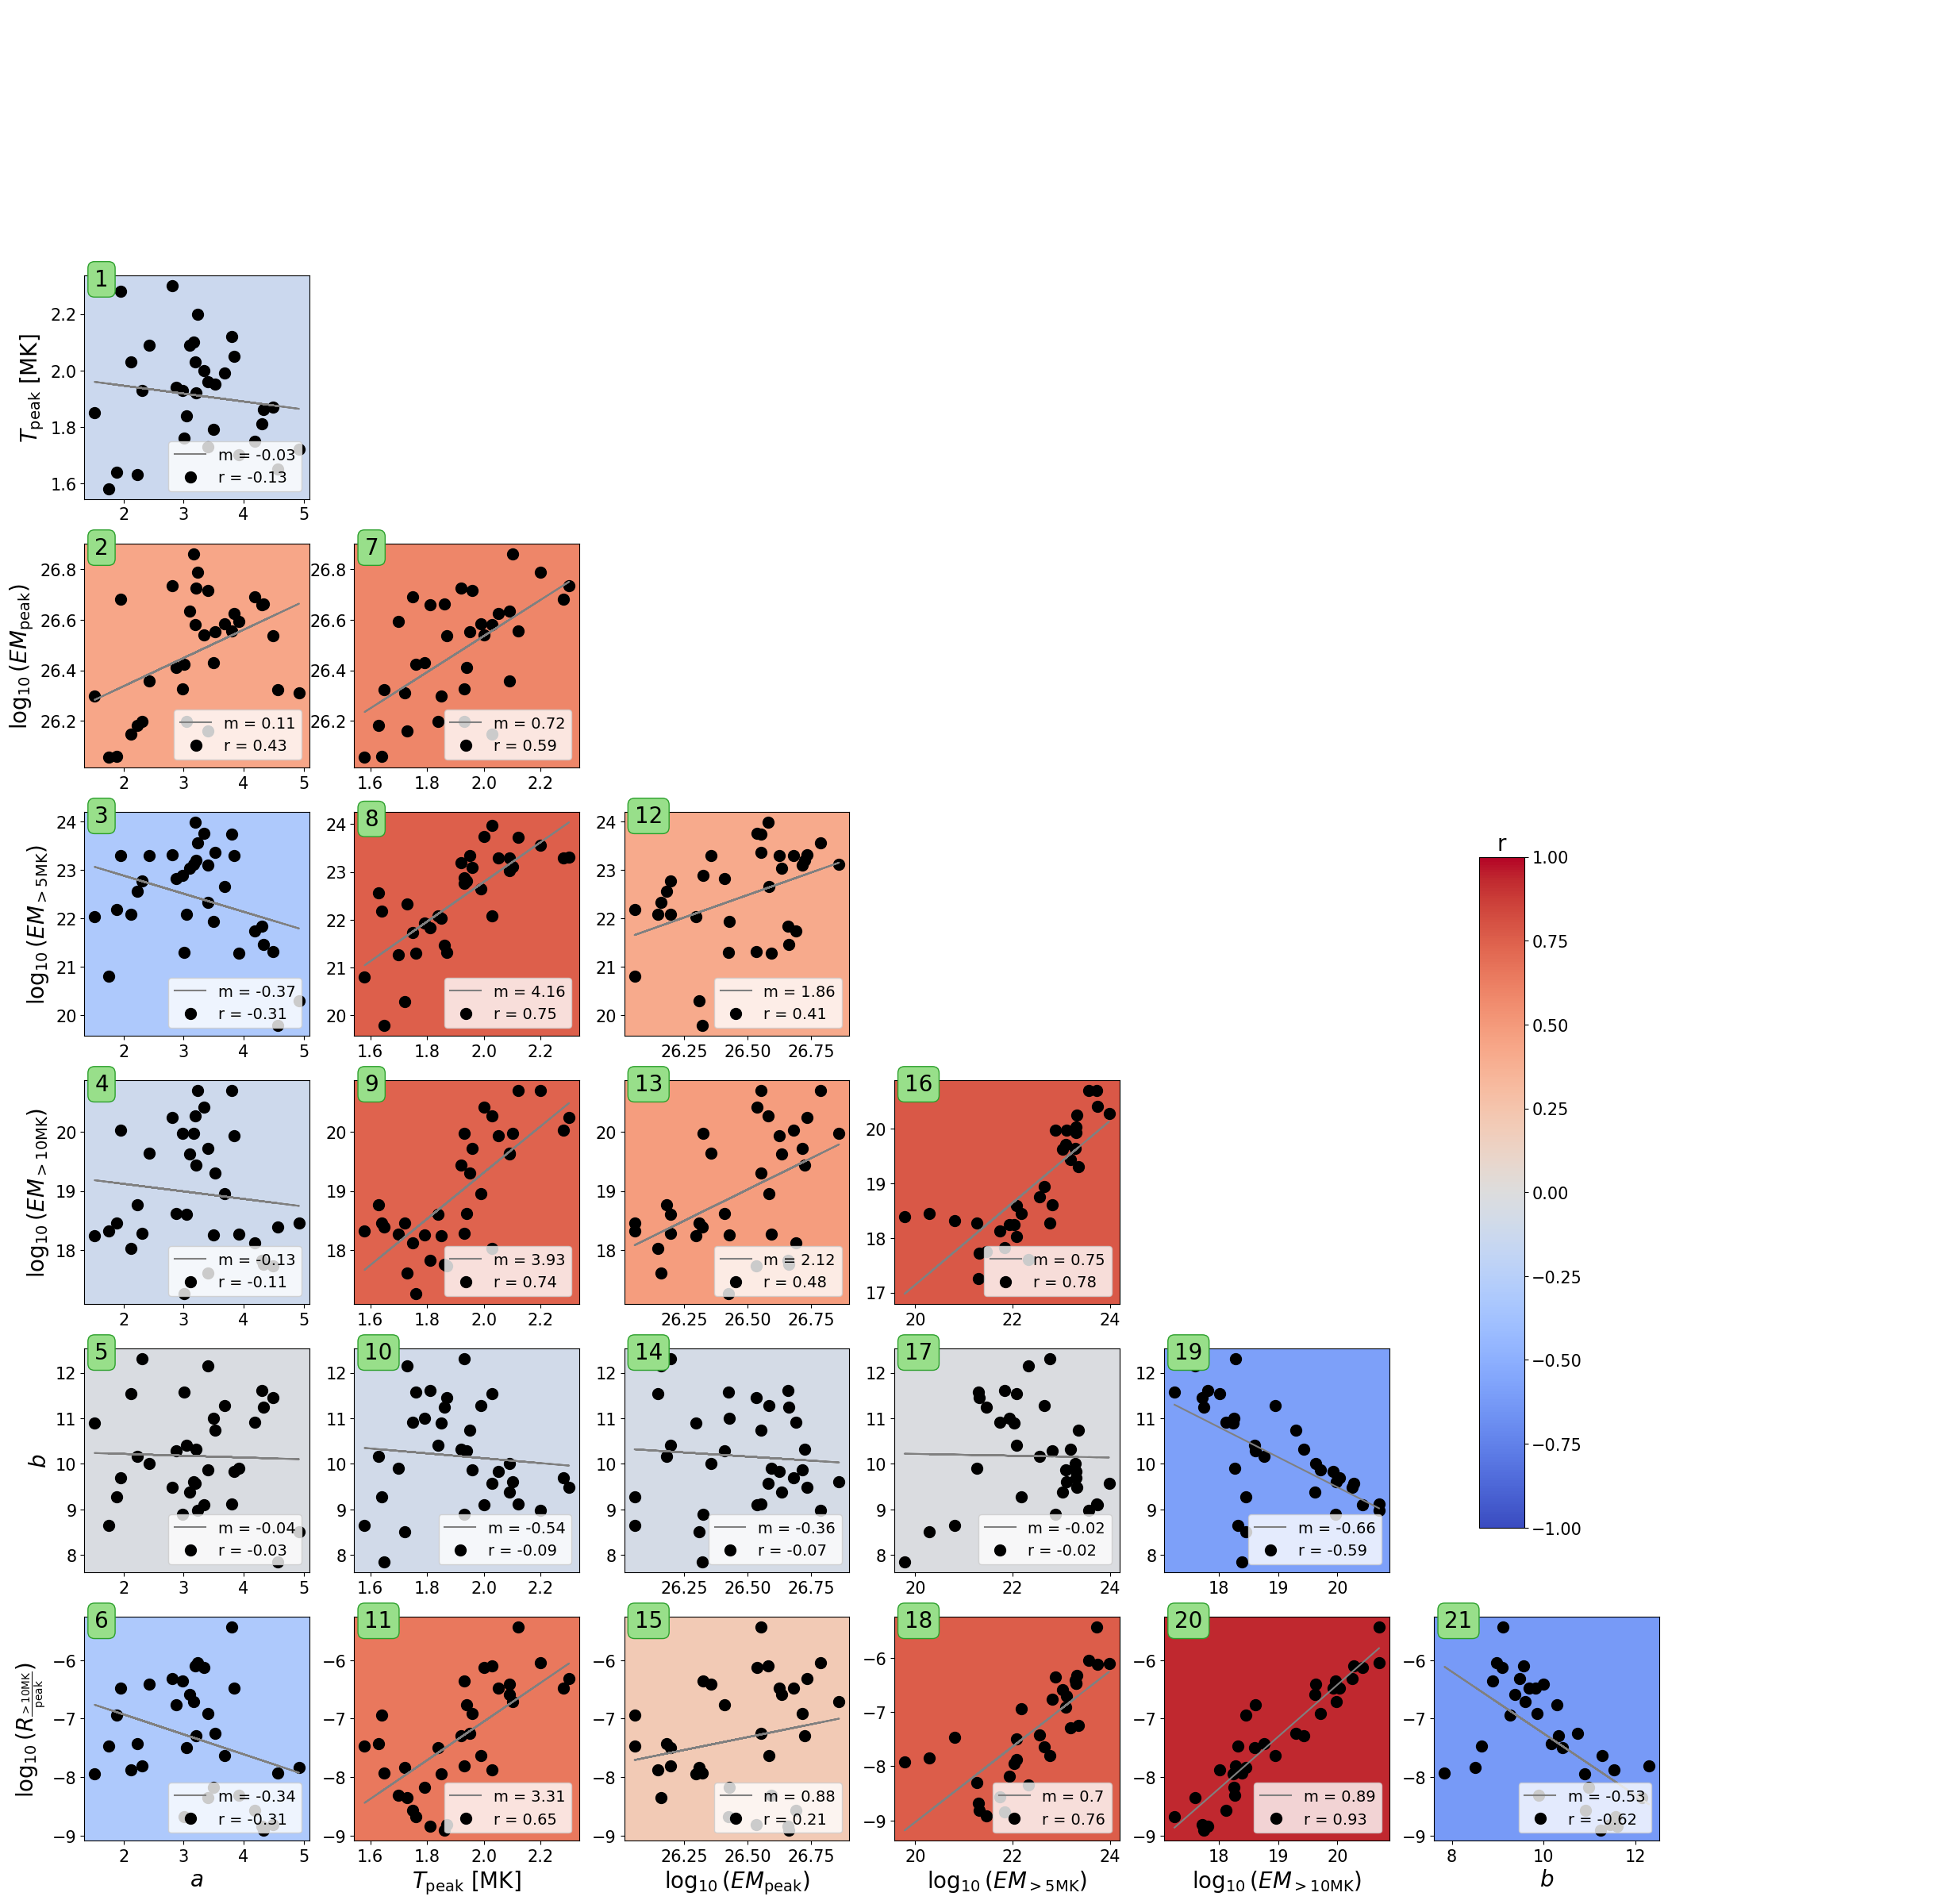

In [7]:
make_cornerplot(filelist, title='ghostcorr')